# Process Evidence Figures — Guardrails & Features

Notebook ini menghasilkan **bukti proses** (mekanisme) bahwa **guardrails** dan **online‑safe features** meningkatkan HR.
Semua gambar disimpan ke `results/figures_process/` dalam format **PDF + PNG**.
Notebook ini menjalankan semua dataset di `DATASETS`.



**Cell ini (konfigurasi & helper)**

- Menetapkan dataset dan metode yang dibandingkan.
- Membaca summary JSON terbaru per model & cache.
- Style plotting mengikuti standar publikasi (serif, grid halus, warna stabil).



In [1]:
from __future__ import annotations
import json, re, statistics
from pathlib import Path
import matplotlib.pyplot as plt

RESULTS_ROOT = Path('results')
OUT_DIR = Path('results/figures_process')
OUT_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = ['wiki2018', 'wikipedia_september_2007']

METHODS_GUARD = ['ilnse_A2_fixed','ilnse_A2_drift_only','ilnse_A2_guard_only','ilnse_A2_full']
LABEL_GUARD = {
    'ilnse_A2_fixed': 'Fixed M',
    'ilnse_A2_drift_only': 'Drift-only',
    'ilnse_A2_guard_only': 'Guard-only',
    'ilnse_A2_full': 'Full',
}

METHODS_FEAT = ['ilnse_A0_full','ilnse_A2_full']
LABEL_FEAT = {'ilnse_A0_full':'A0 (gap only)', 'ilnse_A2_full':'A2 (gap+freq)'}

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'legend.fontsize': 9,
    'lines.linewidth': 2.0,
    'axes.grid': True,
    'grid.linestyle': ':',
    'grid.linewidth': 0.6,
    'grid.alpha': 0.6,
})

PAT = re.compile(r'^(\d{3})_summary_(.+)_(\d+)\.json$')

def save_fig(fig, path: Path):
    fig.tight_layout()
    fig.savefig(path, bbox_inches='tight')
    fig.savefig(path.with_suffix('.png'), dpi=300, bbox_inches='tight')


def load_latest_summaries(dataset_dir: Path):
    records = {}
    for p in dataset_dir.glob('*_summary_*.json'):
        if p.name.endswith('_all_sizes.json'):
            continue
        m = PAT.match(p.name)
        if not m:
            continue
        run_id = int(m.group(1))
        model = m.group(2)
        cache = int(m.group(3))
        key = (model, cache)
        cur = records.get(key)
        if cur is None or run_id > cur[0]:
            records[key] = (run_id, json.loads(p.read_text()))
    return {k: v[1] for k,v in records.items()}


def mean(xs):
    return statistics.mean(xs) if xs else None


def collect_metric(records, model, metric):
    vals = []
    for (m,c), s in records.items():
        if m != model:
            continue
        v = s.get(metric)
        if v is not None:
            vals.append(v)
    return vals


def admitted_rate(records, model):
    rates = []
    for (m,c), s in records.items():
        if m != model:
            continue
        sel = s.get('admit_selected_total')
        cand = s.get('miss_candidates_total')
        if sel is not None and cand:
            rates.append(sel / cand)
    return rates


def hit_yield(records, model):
    vals = []
    for (m,c), s in records.items():
        if m != model:
            continue
        hits = s.get('hits_from_admitted_total')
        applied = s.get('admit_applied_total')
        if hits is not None and applied:
            vals.append(hits / applied)
    return vals



**Cell ini (sanity check data)**

- Menampilkan dataset aktif dan model yang tersedia.
- Pastikan A0, A2, dan varian guardrails tersedia sebelum lanjut.



In [2]:
for dataset in DATASETS:
    ddir = RESULTS_ROOT / dataset
    records = load_latest_summaries(ddir)
    models = sorted({m for (m,_) in records})
    caches = sorted({c for (_,c) in records})
    print('DATASET:', dataset)
    print('models:', models)
    print('caches:', caches)



DATASET: wiki2018
models: ['baseline_lru', 'baseline_lru-k', 'gdbt_A2', 'ilnse_A0_full', 'ilnse_A2_drift_only', 'ilnse_A2_fixed', 'ilnse_A2_full', 'ilnse_A2_guard_only', 'ilnse_xu']
caches: [16123, 20154, 40308, 60463, 80617, 100772]
DATASET: wikipedia_september_2007
models: ['baseline_lru', 'baseline_lru-k', 'gdbt_A2', 'ilnse_A0_full', 'ilnse_A2_drift_only', 'ilnse_A2_fixed', 'ilnse_A2_full', 'ilnse_A2_guard_only', 'ilnse_xu']
caches: [12221, 15277, 30554, 45831, 61109, 76386]


## Fig. G1 — Guardrails Process Evidence (admission, churn, pollution)

**Tujuan:** menunjukkan mekanisme guardrails menekan churn/pollution dan membuat admission lebih konservatif.
**Metrik proses:**
- Admission rate = |A| / |C| (dari summary).
- Avg evictions per slot.
- Pollution rate total.



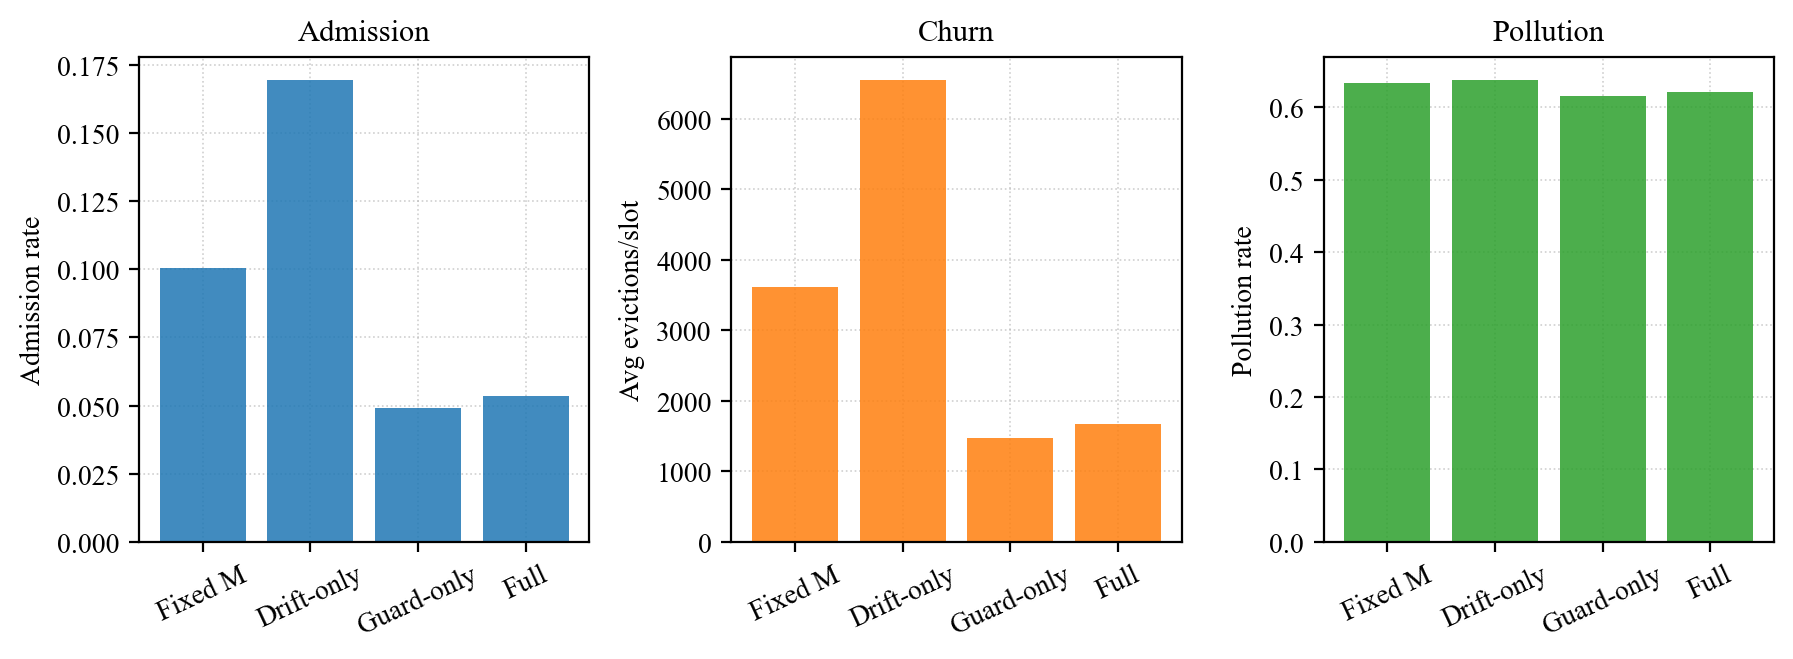

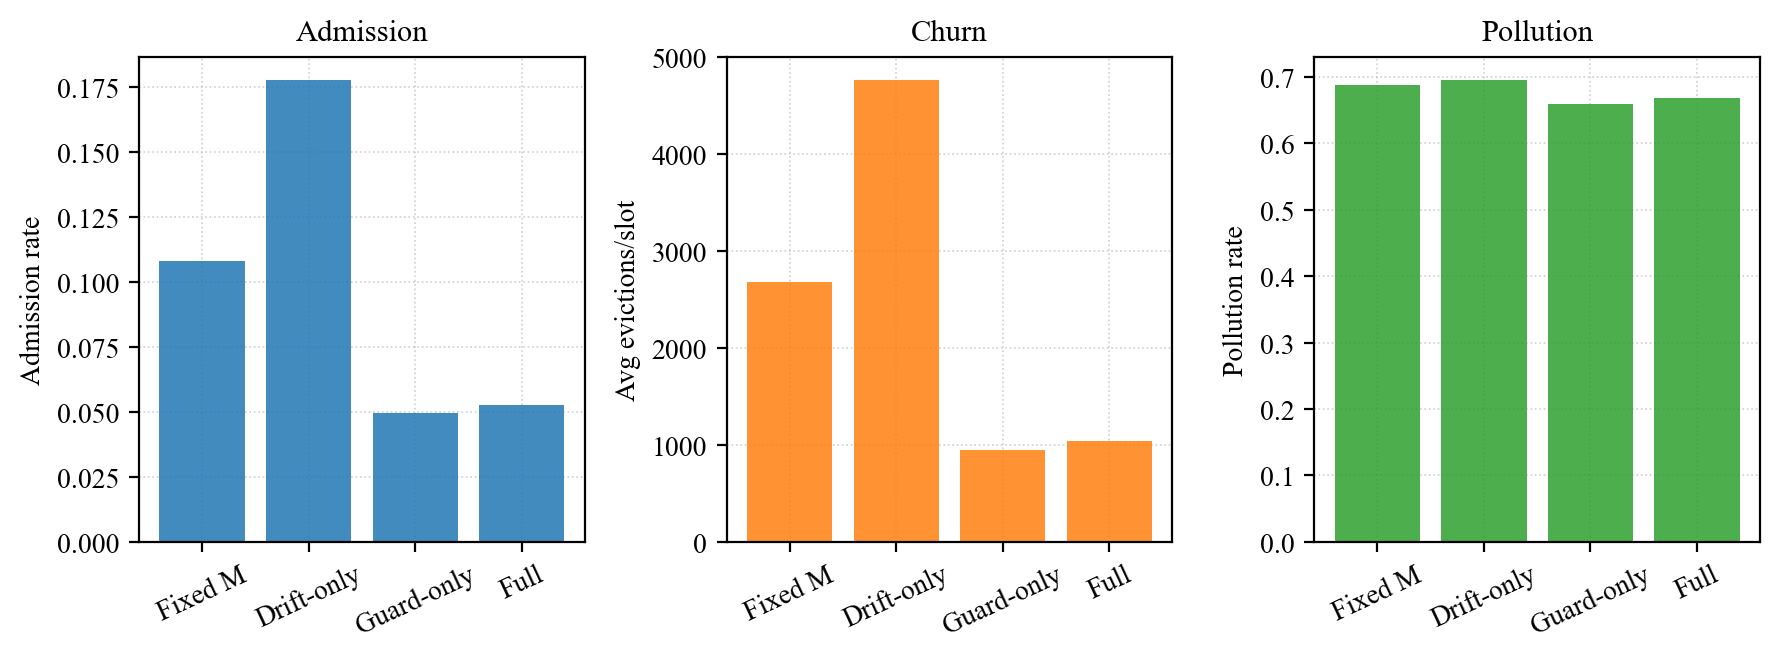

In [3]:
for dataset in DATASETS:
    records = load_latest_summaries(RESULTS_ROOT / dataset)

    labels = [LABEL_GUARD[m] for m in METHODS_GUARD]
    admit_vals = [mean(admitted_rate(records, m)) for m in METHODS_GUARD]
    evict_vals = [mean(collect_metric(records, m, 'cache_evictions_avg')) for m in METHODS_GUARD]
    poll_vals = [mean(collect_metric(records, m, 'pollution_rate_total')) for m in METHODS_GUARD]

    fig, axs = plt.subplots(1, 3, figsize=(9.0, 3.4), dpi=200)
    axs[0].bar(labels, admit_vals, color='#1f77b4', alpha=0.85)
    axs[0].set_ylabel('Admission rate')
    axs[0].set_title('Admission')
    axs[0].tick_params(axis='x', rotation=25)

    axs[1].bar(labels, evict_vals, color='#ff7f0e', alpha=0.85)
    axs[1].set_ylabel('Avg evictions/slot')
    axs[1].set_title('Churn')
    axs[1].tick_params(axis='x', rotation=25)

    axs[2].bar(labels, poll_vals, color='#2ca02c', alpha=0.85)
    axs[2].set_ylabel('Pollution rate')
    axs[2].set_title('Pollution')
    axs[2].tick_params(axis='x', rotation=25)

    for ax in axs:
        ax.set_axisbelow(True)

    out = OUT_DIR / f'fig_G1_guard_process_{dataset}.pdf'
    save_fig(fig, out)



## Fig. G2 — Guardrails Improve Hit‑Yield & Precision

**Tujuan:** menunjukkan bahwa guardrails menaikkan *hit‑yield per admitted* dan precision tertunda.
**Metrik proses:**
- hit‑yield = hits_from_admitted_total / admit_applied_total
- admission_precision_eff_avg (summary)



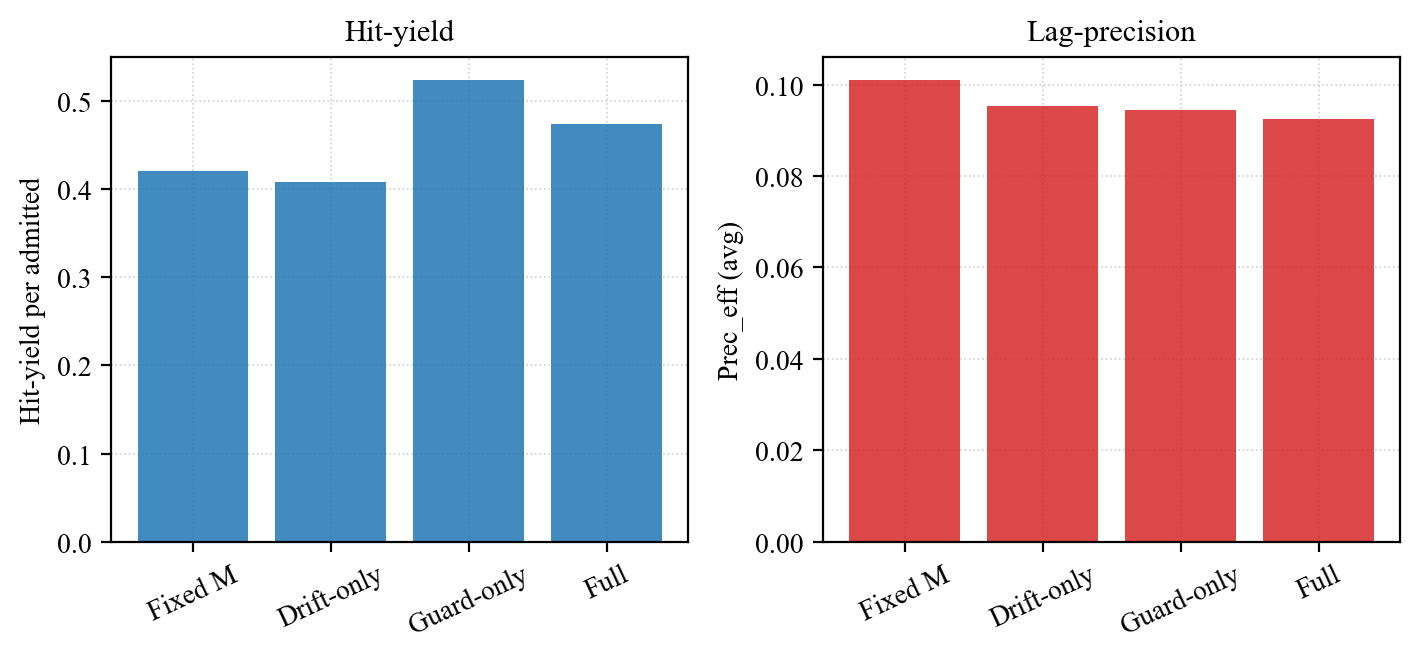

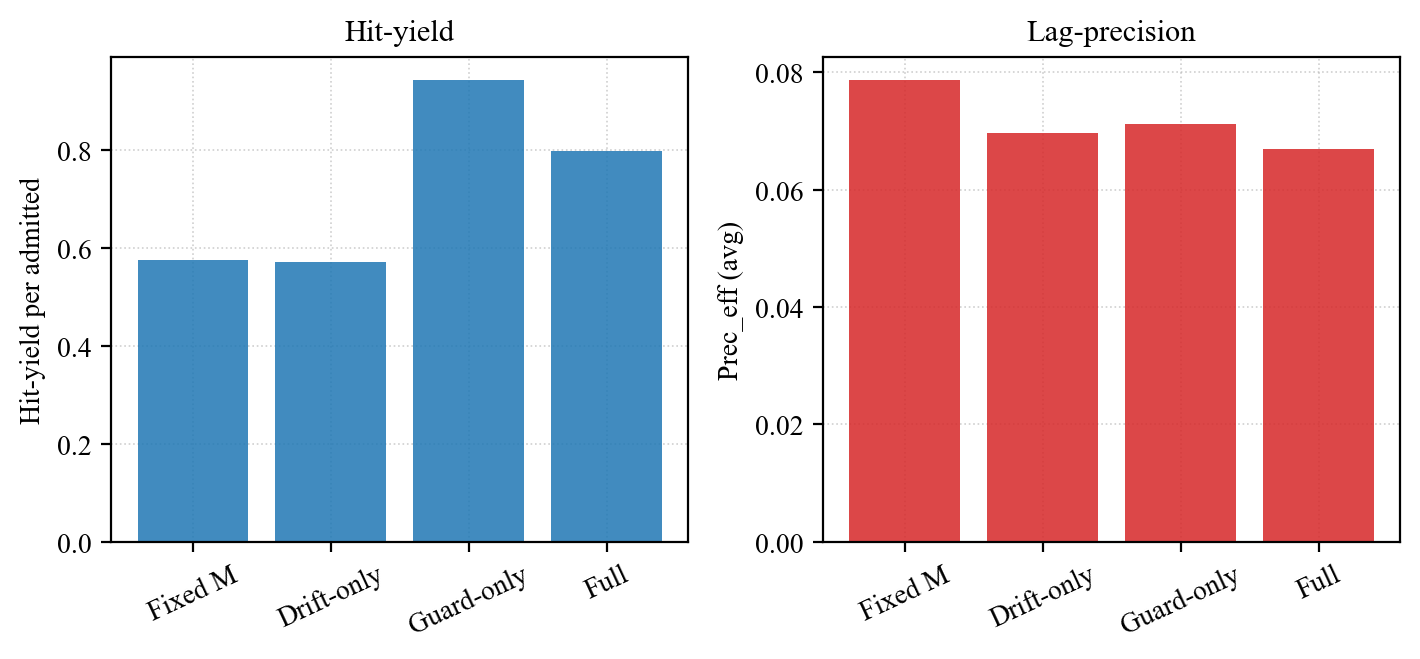

In [5]:
for dataset in DATASETS:
    records = load_latest_summaries(RESULTS_ROOT / dataset)

    labels = [LABEL_GUARD[m] for m in METHODS_GUARD]
    yield_vals = [mean(hit_yield(records, m)) for m in METHODS_GUARD]
    prec_vals = [mean(collect_metric(records, m, 'admission_precision_eff_avg')) for m in METHODS_GUARD]

    fig, axs = plt.subplots(1, 2, figsize=(7.2, 3.4), dpi=200)
    axs[0].bar(labels, yield_vals, color='#1f77b4', alpha=0.85)
    axs[0].set_ylabel('Hit-yield per admitted')
    axs[0].set_title('Hit-yield')
    axs[0].tick_params(axis='x', rotation=25)

    axs[1].bar(labels, prec_vals, color='#d62728', alpha=0.85)
    axs[1].set_ylabel('Prec_eff (avg)')
    axs[1].set_title('Lag-precision')
    axs[1].tick_params(axis='x', rotation=25)

    for ax in axs:
        ax.set_axisbelow(True)

    out = OUT_DIR / f'fig_G2_guard_yield_precision_{dataset}.pdf'
    save_fig(fig, out)



## Fig. F1 — Feature Evidence (Ranking Quality)

**Tujuan:** menunjukkan A2 menghasilkan pemisahan skor lebih baik daripada A0.
**Metrik proses:** score_auc_avg, score_ap_avg, score_precK_avg.



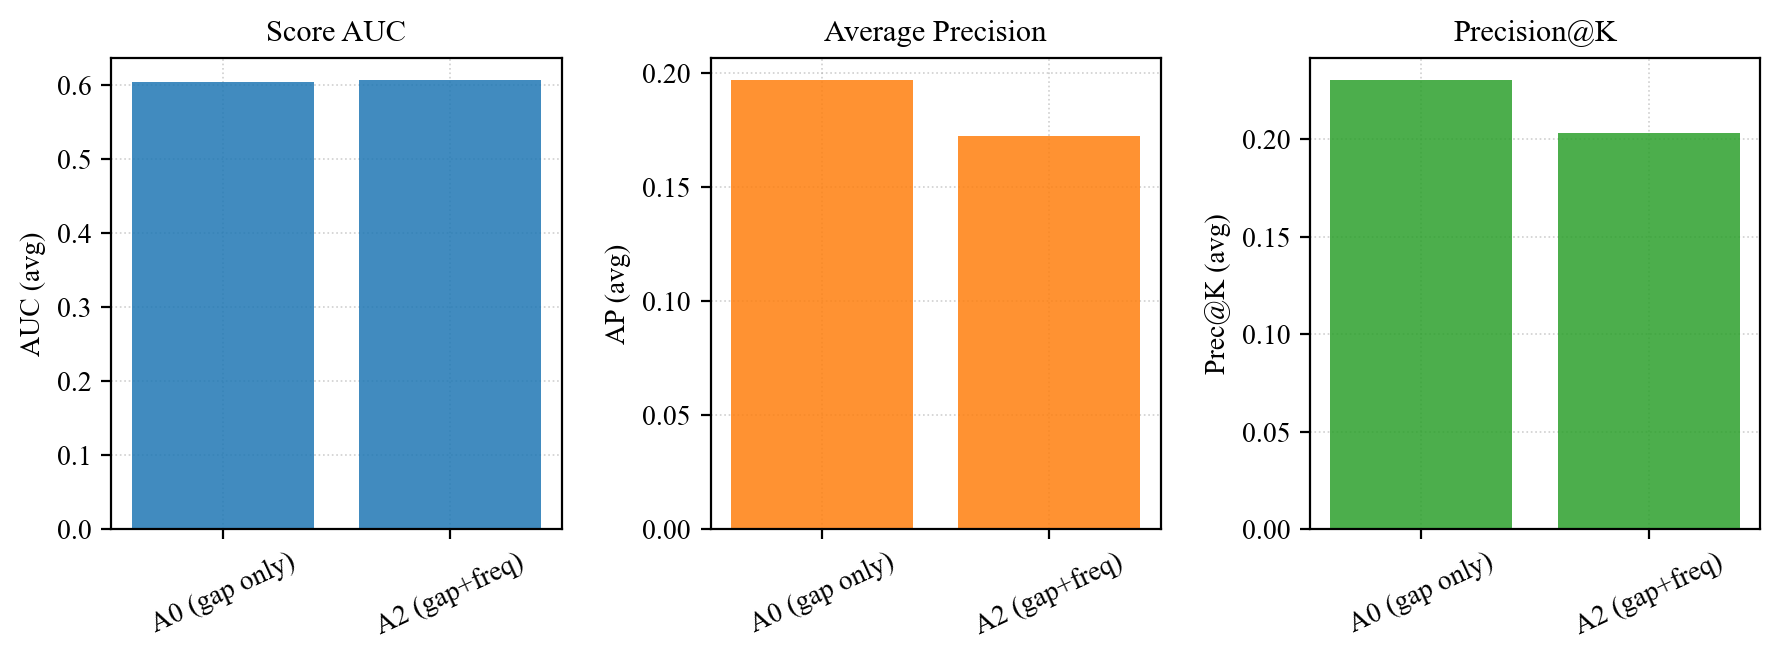

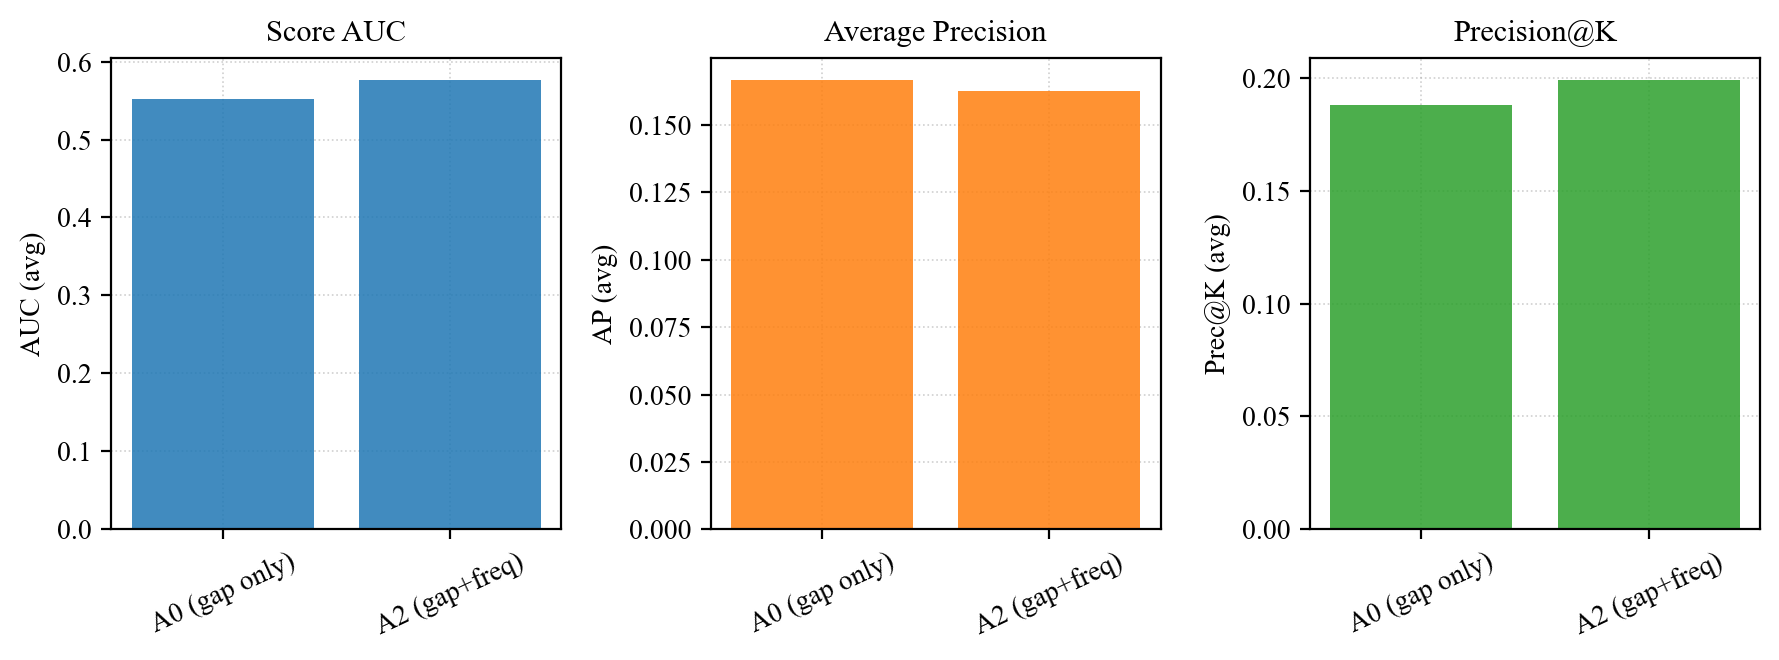

In [6]:
for dataset in DATASETS:
    records = load_latest_summaries(RESULTS_ROOT / dataset)

    labels = [LABEL_FEAT[m] for m in METHODS_FEAT]
    auc_vals = [mean(collect_metric(records, m, 'score_auc_avg')) for m in METHODS_FEAT]
    ap_vals = [mean(collect_metric(records, m, 'score_ap_avg')) for m in METHODS_FEAT]
    pk_vals = [mean(collect_metric(records, m, 'score_precK_avg')) for m in METHODS_FEAT]

    fig, axs = plt.subplots(1, 3, figsize=(9.0, 3.4), dpi=200)
    axs[0].bar(labels, auc_vals, color='#1f77b4', alpha=0.85)
    axs[0].set_ylabel('AUC (avg)')
    axs[0].set_title('Score AUC')
    axs[0].tick_params(axis='x', rotation=25)

    axs[1].bar(labels, ap_vals, color='#ff7f0e', alpha=0.85)
    axs[1].set_ylabel('AP (avg)')
    axs[1].set_title('Average Precision')
    axs[1].tick_params(axis='x', rotation=25)

    axs[2].bar(labels, pk_vals, color='#2ca02c', alpha=0.85)
    axs[2].set_ylabel('Prec@K (avg)')
    axs[2].set_title('Precision@K')
    axs[2].tick_params(axis='x', rotation=25)

    for ax in axs:
        ax.set_axisbelow(True)

    out = OUT_DIR / f'fig_F1_feature_scores_{dataset}.pdf'
    save_fig(fig, out)



## Fig. F2 — Feature Evidence (Hit‑Yield & Precision)

**Tujuan:** menunjukkan A2 membuat admission lebih tepat sasaran.
**Metrik proses:** hit‑yield per admitted, admission_precision_eff_avg.



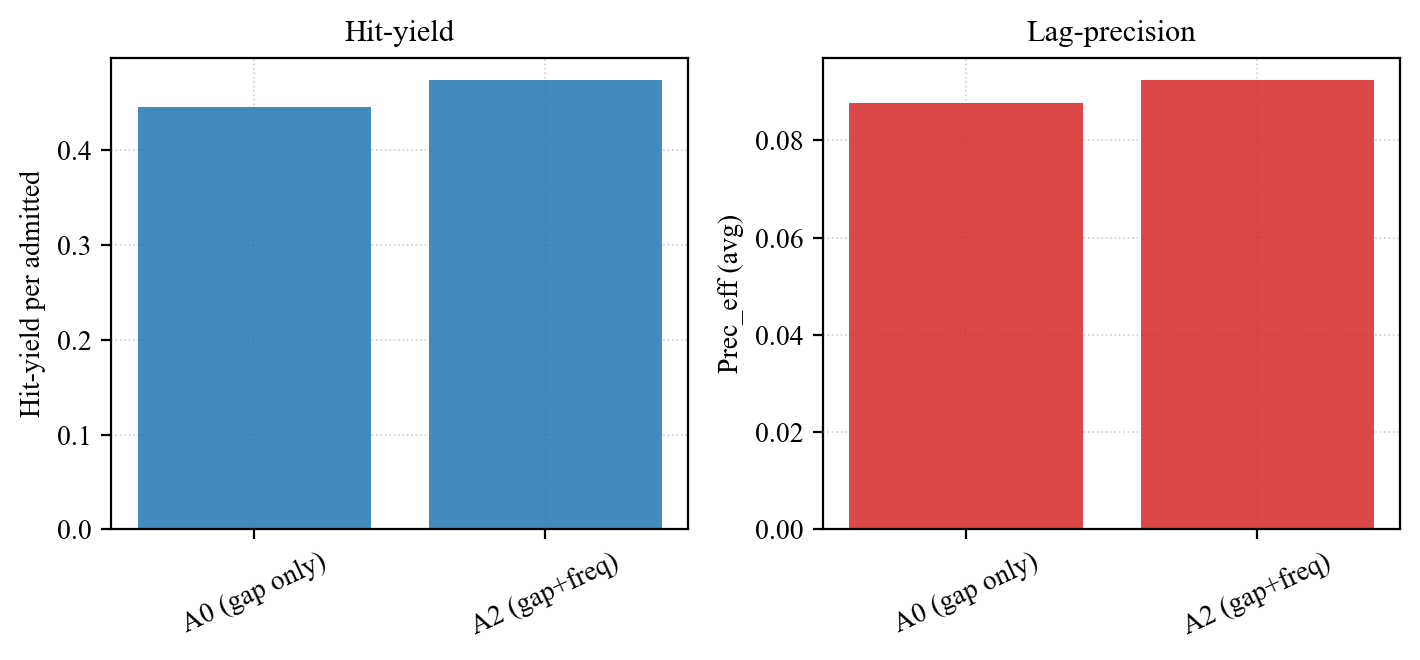

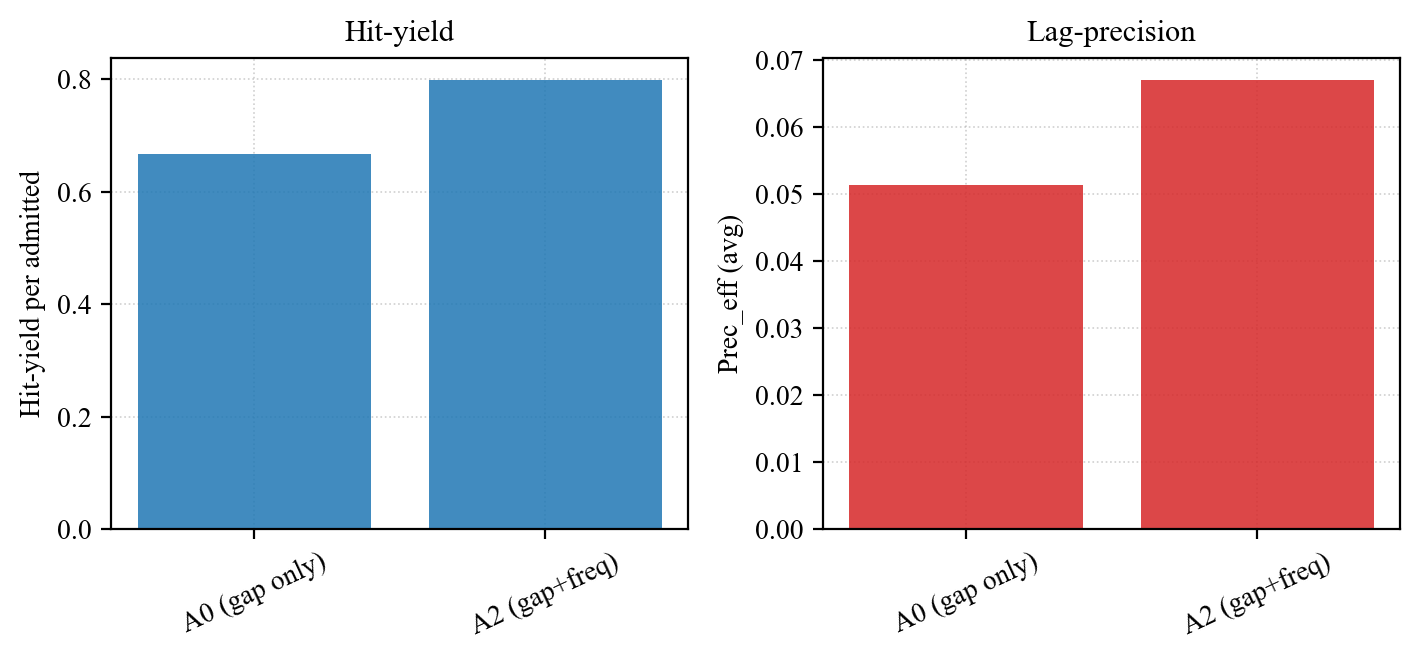

In [8]:
for dataset in DATASETS:
    records = load_latest_summaries(RESULTS_ROOT / dataset)

    labels = [LABEL_FEAT[m] for m in METHODS_FEAT]
    yield_vals = [mean(hit_yield(records, m)) for m in METHODS_FEAT]
    prec_vals = [mean(collect_metric(records, m, 'admission_precision_eff_avg')) for m in METHODS_FEAT]

    fig, axs = plt.subplots(1, 2, figsize=(7.2, 3.4), dpi=200)
    axs[0].bar(labels, yield_vals, color='#1f77b4', alpha=0.85)
    axs[0].set_ylabel('Hit-yield per admitted')
    axs[0].set_title('Hit-yield')
    axs[0].tick_params(axis='x', rotation=25)

    axs[1].bar(labels, prec_vals, color='#d62728', alpha=0.85)
    axs[1].set_ylabel('Prec_eff (avg)')
    axs[1].set_title('Lag-precision')
    axs[1].tick_params(axis='x', rotation=25)

    for ax in axs:
        ax.set_axisbelow(True)

    out = OUT_DIR / f'fig_F2_feature_yield_precision_{dataset}.pdf'
    save_fig(fig, out)

